# Harpocrates detector: how the model was made, and the improvement log

This notebook is the lab notebook for the ML stage of the detector. **Part 0** records how the training data and model were built, from the shipped v0.4 model to today. Each **round** after it is one improvement pass: what was measured, what changed, and the evidence behind each decision. Rounds keep the outputs recorded when they ran.

Rules that hold in every round:
- **Diagnose on validation only.** The held-out LLM benchmark (Kimi K2.6 + MiniMax M2.5) and the OSS test split are never used to pick data, features, extractors, or thresholds (DATA-09). They are scored once per final candidate.
- **No secret values are printed.** All secrets are generated fakes, and examples still appear only as character-class shapes (`A` = upper run, `a` = lower run, `9` = digits).
- Every number here can be reproduced from scripts in `scripts/` and `bench/`; data files are git-ignored and rebuilt by those scripts (provenance: `docs/data.md`).

## Part 0. How the model was made

### 0.1 Starting point: the shipped v0.4 model (measured 2026-09-27)

- **Training data** `data/synthetic_v4.jsonl`, 40,000 records: 20,000 script-generated (`generate_synthetic_data.py`) and 20,000 LLM-generated (LM Studio, `gemma-4-e2b`). Split at random, not by repository. Features were computed per record (`extract_features_from_record`), not on what the scanner actually extracts.
- **Its published number** (97.3% recall) came from a 300-record all-positive holdout. On inspection 111 of those 300 "secrets" (37%) were not secrets: identifiers such as `STRIPE_SECRET_KEY`, words such as `Exception`, and URLs. The holdout was retired.
- **Measured on a clean set** (`test_v1`, below), the full pipeline found **81.5% of secrets at 60.5% precision**. Passwords were at 18% and Twilio at 23%, and it flagged 82% of real-code candidates, approving identifiers like `TextEditorCore_OnSelectionChanged` at 0.86.

### 0.2 An independent, repo-split evaluation set (`scripts/build_eval_set.py`, DATA-02..07)

- **200 permissively licensed OSS repositories** (Apache-2.0 80, BSD-3-Clause 64, MIT 56): 20 per language across Python, JavaScript, TypeScript, Go, Java, Ruby, PHP, Rust, C# and shell. Each is pinned to a commit in `scripts/oss_repos.tsv` and fetched into git-ignored `data/oss/`.
- **Split by a hash of the repo name**: train / val / test = 142 / 16 / 42 repos, so no repository spans two splits.
- **Positives** are fake secrets from deterministic generators (`training/generators/secret_templates.py`), inserted into real files. Insertion styles vary (assignment, dict/map, keyword argument, env default, header, URL query, config block, comment), and so do variable names (secret-sounding, neutral, none).
- **Negatives** are generated look-alikes (UUIDs, git SHAs, checksums, base64 data, doc examples, encoded JSON) plus real scanner candidates taken from the same code. Real strings that gitleaks or a provider regex flags go to a review queue and are never used as negatives.
- **Generator versions** v1 → v5:
  - v2: connection-string kinds and harder negatives (identifiers, paths, placeholders, public keys, integrity hashes).
  - v3: real passwords carry symbols. The v2 look-alikes had taught the model that `$ { %` mean "placeholder".
  - v5: the Twilio label is the auth token, and Slack tokens use the real format.

### 0.3 EDA of the old set against the new one (`scripts/eda_datasets.py`, `EDA_REPORT.md`)

| | synthetic_v4 (40k) | train_v1 (OSS inserts) |
| --- | --- | --- |
| Positives that are not secrets | **31% (6,269)** | 0.4% |
| Positive tokens in a real provider format | 2.1% | 44.6% |
| Distinct secret types | 1 (`ENTROPY_CANDIDATE`) | 27 |
| Unique line shapes | 36.3% | 8.4% |
| P(secret \| secret word on the line) | 68.5% | 83.1% |

The old set's problem was its labels, not its size. Its real strength was variety, so the decision was to keep it, fix its labels, and add realistic data around it.

### 0.4 Cleaning round 1 (`scripts/clean_v4.py`)

Rules, in order:
1. Drop exact (token, line) duplicates: 4,835 removed.
2. Relabel positives that are clearly not secrets as negatives, so they become hard negatives. This covers identifiers and words, URLs and paths, numbers, tokens under 8 characters, and (added after round 1's analysis) dotted and kebab identifiers, with a guard so JWTs and long random segments are never matched.
3. Drop every token still labeled both ways: 498 records.

Result: **34,652 records (11,186 secrets / 23,466 non-secrets), 7,659 relabeled.** Round 2 (section 12) adds three more rules.

### 0.5 LLM-written code with typed slots (`scripts/generate_llm_slots.py`, `scripts/build_slot_set.py`)

- **The LLM writes code only.** It marks each value's position with `{{SECRET:kind}}` or `{{NONSECRET:kind}}`, and a deterministic generator fills the value. Labels are correct by construction, and the LLM never writes or judges a secret.
- **Training generators**, by records:

  | Model | Records |
  | --- | --- |
  | DeepSeek V4 Flash | 5,019 |
  | GPT-6-luna | 4,976 |
  | GPT-5.6-luna | 4,846 |
  | Claude Sonnet 5.5 | 1,464 |
  | DeepSeek V4 Pro | 1,464 |
  | Gemini 3.8 Flash | 1,259 |
  | Gemini 3.7 Flash | 1,196 |
  | Onyx Gemma-4-31B | 907 |
  | Qwen 3.8 Flash | 854 |
  | Gemini 3.6 Flash | 711 |
  | Gemini 3.5 Flash Lite | 663 |
  | Opus 5.5 Light | 578 |

  That's 23,937 records (`llm_train_v5`). Many model families were used deliberately, so the model can't learn one generator's formatting style.
- **Held-out benchmark:** Kimi K2.6 and MiniMax M2.5, families that generated no training data. `benchmark_llm_v5` has 4,352 records.
- **Every CLI ran text-only, with all tools disabled:**
  - codex: `--sandbox read-only`, `--ignore-user-config`
  - claude: `--tools ""` and an empty strict MCP config
  - opencode: `--pure` and a deny-all config
  - agy: plan mode in a sandbox

  An early unrestricted run wrote files into the repo, which is why this lockdown exists.

### 0.6 What each data step bought (ML stage only, threshold for ≥ 90% val recall, 2026-09-28)

| Training data | Records | LLM benchmark recall / precision | TruffleHog-fixture recall |
| --- | --- | --- | --- |
| Shipped v0.4 | n/a | 87.7% / 53.0% | 74.1% |
| cleaned 40k + OSS inserts | 60,344 | 90.2% / 96.8% | 79.1% |
| + GPT-6-luna | 63,071 | 94.0% / 99.6% | 77.3% |
| + GPT-5.6-luna | 65,816 | 95.1% / 99.6% | 76.0% |
| + DeepSeek + Opus | 69,374 | 95.9% / 99.9% | 77.2% |

### 0.7 From record features to scanner candidates (2026-09-29 → 30)

- **The first full-file measurement showed recall was capped by the scanner, not the model.** For example, Azure ML-only recall was 0.99 but full-scan recall 0.18, and Twilio was 1.00 against 0.04.
- **There were two causes:**
  1. Candidate extraction never offered connection strings, token URLs, passwords, or Twilio auth tokens to the model.
  2. Train/serve skew: training used record features, but scanning used features of the extracted candidate.
- **Fixes:**
  - Phase 2d extractors: connection URIs, ADO/ODBC/JDBC password fields, credential query parameters, 32–64-char hex, and password-shaped literals.
  - Pipeline-consistent training (`train_v11.py --pipeline-features`). The scanner runs over each record, and every candidate it extracts becomes a training row, labeled positive only if it overlaps the true secret by at least 4 characters (the same `overlaps()` rule the benchmark uses).
  - A quadratic `extract_var_name` hang on minified lines was found and fixed along the way.
- **Two thresholds from one model (FR-CORE-06):**
  - commit is precision-first, the CLI default;
  - gate is recall-first, used by the read tool and the egress gate.

### 0.8 Round 1 → shipped v16

Round 1, below, found and fixed:
- more label noise (dotted and kebab names);
- a Slack regex that could never match real bot tokens;
- missed Telegram tokens and weak passwords;
- a slow per-line feature window.

It also showed that **variable-name features were a shortcut**: zeroing them *raised* validation AUC. v16 ships with those 10 features zeroed, monotonic constraints, and 2× positive weight.

- **Shipped:** gate threshold 0.5505 and commit threshold 0.8016.
- **Held-out benchmark:** gate 93.3% recall / 92.5% precision, commit 90.2% / 95.1%.
- **OSS test:** gate 98.7% / 93.5%, commit 95.3% / 97.3%.
- **Other scanners on the same benchmark:**

  | Scanner | Recall | Precision |
  | --- | --- | --- |
  | TruffleHog | 40.0% | 97.6% |
  | gitleaks | 52.3% | 89.3% |
  | detect-secrets | 55.3% | 63.8% |
  | CredSweeper | 68.3% | 72.8% |

# Round 1 (2026-09-30): model v15 → v16 (shipped as detector v1.1)

Goal: raise **full-scan recall** at the gate (target ≥ 95%, precision ≥ 80%) and cut scan latency.

Rules for this notebook:
- **Diagnose on validation only.** The held-out LLM benchmark (Kimi + MiniMax) and the OSS test split are never used to pick features, extractors, or thresholds (DATA-09). They are scored once, at the end, per final candidate.
- **No secret values are printed.** Examples are shown as character-class shapes (`A`=upper run, `a`=lower run, `9`=digits).
- Model under study: `data/models/v15.json` (data v5, trained on scanner candidates; gate threshold from `v15.report.json`).

In [1]:
import json, sys, time, re, collections
from pathlib import Path
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "bench" else Path.cwd()
sys.path[:0] = [str(ROOT / "cli"), str(ROOT / "scripts"), str(ROOT)]
import train_v11 as T
from Harpocrates.core.detector import _collect_text_findings, _prepare_ml_context_from_lines
from Harpocrates.core.result import EvidenceType
from Harpocrates.ml.features import FeatureVector, extract_features
from bench.compare_scanners import overlaps

E = ROOT / "data" / "eval"
NAMES = FeatureVector.get_feature_names()
report = json.loads((ROOT / "data/models/v15.report.json").read_text())
GATE = report["thresholds"]["0.97"]
booster = xgb.Booster(); booster.load_model(str(ROOT / "data/models/v15.json"))

def shape(s):
    return re.sub(r"[a-z]+", "a", re.sub(r"[A-Z]+", "A", re.sub(r"\d+", "9", s)))[:24]

# Rebuild the exact train/val split used by train_v11 (same files, same hash holdout).
train_files = [ROOT / "data/synthetic_v4_clean.jsonl", E / "train_v5.jsonl", E / "llm_train_v5.jsonl"]
train, val = [], T.load(E / "val_v5.jsonl")
for p in train_files:
    for r in T.load(p):
        (val if not p.name.startswith("train_v") and T.is_holdout(r) else train).append(r)
keys = {(r["token"], r["line_content"]) for r in train}
val = [r for r in val if (r["token"], r["line_content"]) not in keys]
print(f"train records {len(train)}, val records {len(val)} (val positives {sum(r['label'] for r in val)}), gate threshold {GATE:.4f}")

train records 82775, val records 8778 (val positives 3762), gate threshold 0.4124


## 1. Recall ceiling: which secrets never become a candidate?

A secret the scanner never extracts cannot be caught by any threshold. For each validation positive we check whether *any* candidate on its line overlaps it (regex hits included), and if not, classify why.

In [2]:
def candidates(r):
    before = r.get("context_before", [])
    lines = [*before, r["line_content"], *r.get("context_after", [])]
    target = len(before) + 1
    return lines, target, [f for f in _collect_text_findings("\n".join(lines)) if f.line == target and f.token]

def miss_reason(tok, line_cands):
    if line_cands:
        return "candidate on line, no overlap"
    if re.search(r"\s", tok): return "contains whitespace"
    if len(tok) < 8: return "shorter than 8"
    if len(tok) < 20 and not re.search(r"[:=@;&?]", tok): return "8-19 chars, no name/structure hook"
    if re.search(r"[;:@/?&]", tok): return "delimiters split the token"
    return "other"

rows = []
t0 = time.perf_counter()
for i, r in enumerate(val):
    if r["label"] != 1: continue
    _lines, _t, cands = candidates(r)
    hit = [f for f in cands if overlaps(f.token, r["token"])]
    rows.append(dict(i=i, type=r.get("secret_type", "unknown"), source=r.get("source"), covered=bool(hit),
                     regex=any(f.evidence == EvidenceType.REGEX for f in hit),
                     reason=None if hit else miss_reason(r["token"], cands), shape=shape(r["token"])))
print(f"{len(rows)} positives in {time.perf_counter()-t0:.0f}s; ceiling = {np.mean([x['covered'] for x in rows]):.3f}")
by_type = collections.defaultdict(lambda: [0, 0])
for x in rows: by_type[x["type"]][0] += x["covered"]; by_type[x["type"]][1] += 1
print(f"{'type':26}{'coverage':>9}{'n':>6}")
for t, (c, n) in sorted(by_type.items(), key=lambda kv: kv[1][0] / kv[1][1])[:14]:
    print(f"{t:26}{c/n:9.2f}{n:6}")

3762 positives in 0s; ceiling = 0.961
type                       coverage     n
password                       0.84    97
ENTROPY_CANDIDATE              0.90  1100
generic_random                 0.94   108
discord_token                  0.96   127
jdbc_url                       0.98    85
jwt                            0.99   111
azure_connection_string        0.99   112
vault_token                    0.99   117
digitalocean_token             0.99   118
connection_uri                 1.00    92
ado_connection_string          1.00    80
twilio_sid                     1.00   111
gcp_api_key                    1.00   124
github_fine_grained            1.00   112


In [3]:
miss = [x for x in rows if not x["covered"]]
print(f"uncovered positives: {len(miss)}")
print("by reason:", collections.Counter(x["reason"] for x in miss).most_common())
print()
for t in sorted({x['type'] for x in miss}, key=lambda t: -sum(x['type'] == t for x in miss))[:8]:
    xs = [x for x in miss if x["type"] == t]
    print(f"{t:24} n={len(xs):4}  reasons={dict(collections.Counter(x['reason'] for x in xs).most_common(3))}")
    print(f"{'':24} shapes={[s for s, _ in collections.Counter(x['shape'] for x in xs).most_common(4)]}")

uncovered positives: 146
by reason: [('8-19 chars, no name/structure hook', 58), ('candidate on line, no overlap', 47), ('delimiters split the token', 24), ('other', 14), ('shorter than 8', 3)]

ENTROPY_CANDIDATE        n= 112  reasons={'8-19 chars, no name/structure hook': 49, 'candidate on line, no overlap': 41, 'delimiters split the token': 14}
                         shapes=['AaAa-', 'a/a-a', 'a_a9', '9/a']
password                 n=  16  reasons={'8-19 chars, no name/structure hook': 9, 'shorter than 8': 3, 'delimiters split the token': 2}
                         shapes=['Aa9', 'a$', 'AaAa@a', 'a9%a']
generic_random           n=   7  reasons={'delimiters split the token': 7}
                         shapes=[',A](A[+aAa9+9*9,a>a?aA,a', 'a;a:-a)+}&-Aa*A*,Aa%a!>{', '%aAaA9;9a{a9]a@a9a?#AaAa', '&_:9aAaAa9)a+AaA|},A9$Aa']
discord_token            n=   5  reasons={'other': 4, 'candidate on line, no overlap': 1}
                         shapes=['AaAa9AaA9AaAa.aAaA9a.aAa', 'AaAa9A9Aa9A

## 2. Model rejections: covered secrets the gate still drops

For covered positives whose best overlapping candidate scores below the gate threshold, which features push the score down? SHAP values come from XGBoost's exact TreeSHAP (`pred_contribs`).

In [4]:
rej_X, acc_X, rej_types = [], [], []
for x in rows:
    if not x["covered"]: continue
    r = val[x["i"]]
    lines, target, cands = candidates(r)
    best = None
    for f in cands:
        if f.evidence == EvidenceType.REGEX or not overlaps(f.token, r["token"]):
            continue
        import dataclasses
        f = dataclasses.replace(f, file="record" + (r.get("file_type") or ""))
        v = extract_features(f, _prepare_ml_context_from_lines(f, lines)).to_array()
        p = float(booster.predict(xgb.DMatrix(np.array([v], dtype=np.float32)))[0])
        if best is None or p > best[0]: best = (p, v)
    if best is None: continue  # caught by regex, no ML decision
    (acc_X if best[0] >= GATE else rej_X).append(best[1])
    if best[0] < GATE: rej_types.append(x["type"])
print(f"ML-decided positives: accepted {len(acc_X)}, rejected {len(rej_X)}  -> rejection rate {len(rej_X)/max(len(rej_X)+len(acc_X),1):.3f}")
print("rejected by type:", collections.Counter(rej_types).most_common(8))

ML-decided positives: accepted 2225, rejected 81  -> rejection rate 0.035
rejected by type: [('ENTROPY_CANDIDATE', 61), ('password', 9), ('twilio_sid', 6), ('ado_connection_string', 3), ('generic_random', 2)]


feature                             rejected  accepted
token_entropy                         -0.302     0.498
uppercase_ratio                       -0.187     0.247
var_ngram_secret_score                -0.072     0.233
char_class_count                      -0.122     0.173
digit_ratio                           -0.044     0.221
semantic_context_score                -0.057     0.189
token_length                           0.018     0.251
special_char_ratio                     0.037     0.234
token_span_offset                      0.128     0.309
has_padding                            0.020     0.193
var_ngram_safe_score                  -0.074     0.060
surrounding_secret_density            -0.010     0.107


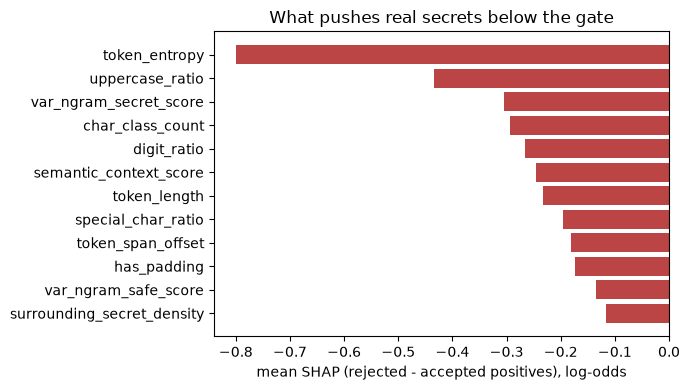

In [5]:
def shap_mean(X):
    c = booster.predict(xgb.DMatrix(np.array(X, dtype=np.float32)), pred_contribs=True)
    return c[:, :-1].mean(axis=0)  # drop bias column
s_rej, s_acc = shap_mean(rej_X), shap_mean(acc_X)
order = np.argsort(s_rej - s_acc)[:12]  # features pushing rejected positives down the most, relative to accepted
print(f"{'feature':34}{'rejected':>10}{'accepted':>10}")
for j in order: print(f"{NAMES[j]:34}{s_rej[j]:10.3f}{s_acc[j]:10.3f}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([NAMES[j] for j in order][::-1], (s_rej - s_acc)[order][::-1], color="#b44")
ax.set_xlabel("mean SHAP (rejected - accepted positives), log-odds"); ax.set_title("What pushes real secrets below the gate")
plt.tight_layout(); plt.show()

### Findings from the first pass (model v14, data v4), and what changed for v15

| Finding | Evidence | Change in v15 |
| --- | --- | --- |
| Ceiling 89.7% on val; 303 of 403 uncovered "secrets" were old-40k label noise | dotted names (`signer.verifySignature`), kebab placeholders (`your-github-client-id`) labeled 1 | `clean_v4` relabels dotted/kebab identifiers |
| Slack coverage 69% | generator emitted `xoxb-` + 3 all-digit parts; our regex capped the secret at 34 chars, so real bot tokens (`xoxb-<d>-<d>-<24 alnum>`) could never match | real-format generator; regex cap 48 |
| Passwords 64% | lowercase+digit passwords (`hunter42`) not "password-shaped" | accept ≥3 letters + ≥2 digits |
| Telegram tokens missed inside bot URLs | URL stripping; no Telegram rule | `TELEGRAM_BOT_TOKEN` HIGH regex + category |
| ML rejects only 3.4% of covered positives | SHAP: low entropy / low digit ratio (mostly the mislabeled records) | fixed by relabeling, not by the model |
| p99 94 ms, max 4.2 s per file | features scanned whole 100k-char lines; file extension recomputed per line | ±256-char context window; per-file extension cache |


## 3. Speed: where does scan time go?

Profile the full `detect_file_with_ml` path (the CLI's `scan --ml`) over files sampled from the OSS test-split repos, using the gate model.

In [6]:
import cProfile, pstats, random, csv
sys.path.insert(0, str(ROOT / "bench"))
from bench.eval_detector import _onnx_verifier
from Harpocrates.core.detector import detect_file_with_ml
import build_eval_set as B

verifier = _onnx_verifier(ROOT / "data/models/cand_v15_gate")
with open(ROOT / "scripts/oss_repos.tsv") as f:
    repos = [r["repo"] for r in csv.DictReader(f, delimiter="\t") if B.split_of(r["repo"]) == "test"]
files = [p for repo in repos for p in B._files(ROOT / "data/oss" / repo.replace("/", "__"))]
random.seed(0); sample = random.sample(files, 400)
times = []
prof = cProfile.Profile(); prof.enable()
for p in sample:
    t = time.perf_counter(); detect_file_with_ml(p, verifier, ml_threshold=0.19)
    times.append((time.perf_counter() - t, p.stat().st_size, max((len(l) for l in p.read_text(errors="replace").splitlines()), default=0)))
prof.disable()
ts = np.array([t for t, _, _ in times]) * 1000
print(f"{len(ts)} files: p50={np.percentile(ts,50):.1f}ms  p95={np.percentile(ts,95):.1f}ms  p99={np.percentile(ts,99):.1f}ms  max={ts.max():.0f}ms  total={ts.sum()/1000:.1f}s")
slow = sorted(times, reverse=True)[:5]
print("slowest files (ms, bytes, longest line):", [(round(t*1000), b, l) for t, b, l in slow])
pstats.Stats(prof).sort_stats("cumulative").print_stats(14)

400 files: p50=1.8ms  p95=14.4ms  p99=87.0ms  max=217ms  total=2.3s
slowest files (ms, bytes, longest line): [(217, 99516, 121), (212, 92651, 32041), (203, 59690, 237), (142, 82804, 557), (86, 8853, 99)]
         6657605 function calls (6652949 primitive calls) in 2.346 seconds

   Ordered by: cumulative time
   List reduced from 481 to 14 due to restriction <14>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      120    0.001    0.000    1.620    0.014 /Users/joshuado/harpocrates/cli/Harpocrates/core/detector.py:578(_apply_ml_verification)
      400    0.065    0.000    1.330    0.003 /Users/joshuado/harpocrates/cli/Harpocrates/core/detector.py:475(_collect_file_findings)
    74876    0.422    0.000    1.078    0.000 /Users/joshuado/harpocrates/cli/Harpocrates/core/detector.py:210(_scan_line)
      120    0.001    0.000    0.903    0.008 /Users/joshuado/harpocrates/cli/Harpocrates/core/detector.py:644(_apply_ml_verification_with_contexts)
      120    0.139 

## 4. Feature importance (validation, candidate level)

Mean |SHAP| per feature over validation candidates, and XGBoost gain. Features with high importance but no causal link to "is a secret" (names, file hints) are shortcut risks.

train candidates 86857 (pos 0.313), val candidates 11735 (pos 0.239)


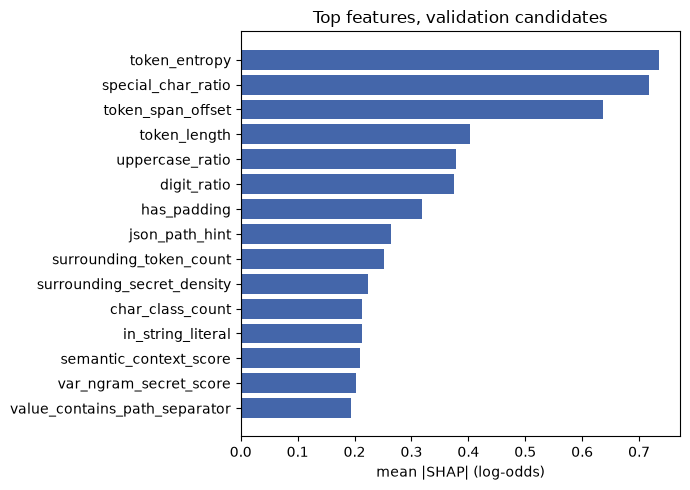

In [7]:
Xtr, ytr = T.xy(train, True)
Xva, yva = T.xy(val, True)
print(f"train candidates {len(ytr)} (pos {ytr.mean():.3f}), val candidates {len(yva)} (pos {yva.mean():.3f})")
contrib = booster.predict(xgb.DMatrix(Xva), pred_contribs=True)[:, :-1]
imp = np.abs(contrib).mean(axis=0)
top = np.argsort(imp)[::-1][:15]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([NAMES[j] for j in top][::-1], imp[top][::-1], color="#46a")
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("Top features, validation candidates")
plt.tight_layout(); plt.show()

## 5. Feature-group ablation

Retrain with one group zeroed (same params, cached features) and compare validation **AUC** and **recall at 5% FPR**. A group whose removal barely hurts, or helps, is carrying shortcuts.

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve
GROUPS = {
    "token shape": [n for n in NAMES if n.startswith(("token_", "char_", "digit_", "uppercase_", "special_", "is_", "has_", "entropy_", "jwt_", "embedded_", "vendor_", "regex_"))],
    "value shape": [n for n in NAMES if n.startswith("value_")],
    "variable name": [n for n in NAMES if n.startswith(("var_", "assignment_", "key_value_", "adjacency_"))],
    "surrounding context": [n for n in NAMES if n.startswith(("context_", "surrounding_", "semantic_", "line_", "in_string", "json_", "env_", "hex_context", "hex_adjacent", "hex_in"))],
    "file type": [n for n in NAMES if n.startswith(("file_", "hex_file"))],
}
P = dict(T.PARAMS); P.pop("eval_metric", None)
def fit_eval(Xa, Xb, **extra):
    m = xgb.XGBClassifier(**P, **extra).fit(Xa, ytr)
    p = m.predict_proba(Xb)[:, 1]
    fpr, tpr, _ = roc_curve(yva, p)
    return roc_auc_score(yva, p), float(np.interp(0.05, fpr, tpr)), m
base_auc, base_r5, _ = fit_eval(Xtr, Xva)
print(f"{'dropped group':22}{'n feats':>8}{'AUC':>8}{'recall@5%FPR':>14}")
print(f"{'(none)':22}{0:8}{base_auc:8.4f}{base_r5:14.4f}")
for g, feats in GROUPS.items():
    idx = [NAMES.index(f) for f in feats]
    Za, Zb = Xtr.copy(), Xva.copy(); Za[:, idx] = 0; Zb[:, idx] = 0
    auc, r5, _ = fit_eval(Za, Zb)
    print(f"{g:22}{len(idx):8}{auc:8.4f}{r5:14.4f}")

dropped group          n feats     AUC  recall@5%FPR
(none)                       0  0.9915        0.9575


token shape                 25  0.9685        0.8134


value shape                  6  0.9914        0.9615


variable name               10  0.9944        0.9804


surrounding context         16  0.9786        0.8616


file type                    7  0.9924        0.9611


## 6. Recall-oriented training: class weighting and monotonic constraints

- `scale_pos_weight` makes missed secrets costlier than false alarms (the gate's priority).
- Monotonic constraints forbid nonsense directions: higher entropy, a vendor prefix, a secret-sounding name or a failed-placeholder check can never *lower* the score.

In [9]:
mono = {"token_entropy": 1, "vendor_prefix_boost": 1, "var_ngram_secret_score": 1, "jwt_structure_valid": 1,
        "value_is_template_syntax": -1, "is_uuid_v4": -1, "has_version_pattern": -1}
constraints = "(" + ",".join(str(mono.get(n, 0)) for n in NAMES) + ")"
print(f"{'variant':34}{'AUC':>8}{'recall@5%FPR':>14}")
print(f"{'baseline':34}{base_auc:8.4f}{base_r5:14.4f}")
for label, extra in [("scale_pos_weight=2", dict(scale_pos_weight=2.0)),
                     ("scale_pos_weight=4", dict(scale_pos_weight=4.0)),
                     ("monotonic", dict(monotone_constraints=constraints)),
                     ("monotonic + scale_pos_weight=2", dict(monotone_constraints=constraints, scale_pos_weight=2.0))]:
    auc, r5, _ = fit_eval(Xtr, Xva, **extra)
    print(f"{label:34}{auc:8.4f}{r5:14.4f}")

variant                                AUC  recall@5%FPR
baseline                            0.9915        0.9575


scale_pos_weight=2                  0.9936        0.9690


scale_pos_weight=4                  0.9939        0.9707


monotonic                           0.9922        0.9633


monotonic + scale_pos_weight=2      0.9923        0.9604


## 7. Calibration (FR-CORE-03)

Is a score of 0.8 right 80% of the time? A calibrated score makes the gate threshold stable across retrains.

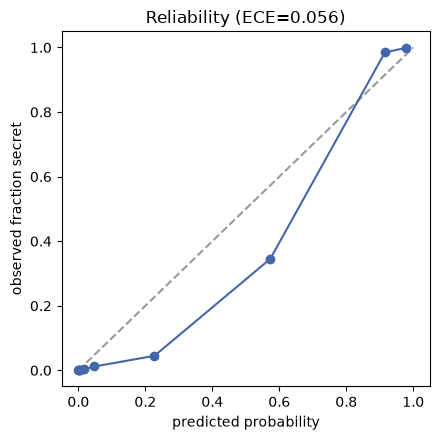

In [10]:
from sklearn.calibration import calibration_curve
p_val = booster.predict(xgb.DMatrix(Xva))
frac, mean_p = calibration_curve(yva, p_val, n_bins=10, strategy="quantile")
bins = np.quantile(p_val, np.linspace(0, 1, 11)); ids = np.clip(np.digitize(p_val, bins[1:-1]), 0, 9)
ece = sum(abs(p_val[ids == b].mean() - yva[ids == b].mean()) * (ids == b).mean() for b in range(10) if (ids == b).any())
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="#999"); ax.plot(mean_p, frac, "o-", color="#46a")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed fraction secret"); ax.set_title(f"Reliability (ECE={ece:.3f})")
plt.tight_layout(); plt.show()

## 8. Distribution shift: training vs held-out benchmark candidates

A classifier tries to tell training candidates from benchmark candidates using **features only (no benchmark labels)**. AUC near 0.5 means no shift; the most separating features are where the model may not generalize. This is the one place the benchmark is touched before final scoring, and only its unlabeled features.

In [11]:
bench = [r for r in T.load(E / "benchmark_llm_v5.jsonl") if (r["token"], r["line_content"]) not in keys]
Xb, _ = T.xy(bench, True)
rng = np.random.default_rng(0); sub = rng.choice(len(Xtr), size=min(len(Xtr), 4 * len(Xb)), replace=False)
Xs, ys = np.vstack([Xtr[sub], Xb]), np.r_[np.zeros(len(sub)), np.ones(len(Xb))]
perm = rng.permutation(len(ys)); cut = int(0.7 * len(ys))
adv = xgb.XGBClassifier(max_depth=4, n_estimators=150, learning_rate=0.1).fit(Xs[perm[:cut]], ys[perm[:cut]])
print(f"adversarial AUC (train vs benchmark candidates) = {roc_auc_score(ys[perm[cut:]], adv.predict_proba(Xs[perm[cut:]])[:, 1]):.3f}")
g = adv.get_booster().get_score(importance_type="gain")
print("most separating features:", [(NAMES[int(k[1:])], round(v, 1)) for k, v in sorted(g.items(), key=lambda kv: -kv[1])[:8]])

adversarial AUC (train vs benchmark candidates) = 0.899
most separating features: [('special_char_ratio', 96.7), ('env_loader_in_context', 50.3), ('json_path_hint', 44.7), ('embedded_token_flag', 34.1), ('file_is_config', 29.3), ('adjacency_ngram_score', 19.2), ('hex_context_crypto_keywords', 14.4), ('var_ngram_secret_score', 14.2)]


## 9. Head-to-head (final scoring, full file scans)

Scored once per final candidate on the held-out benchmark and OSS test split. detect-secrets is matched per line (it reports only a hash of each secret), which is lenient in its favor. CredSweeper's AUC uses its ML probabilities at `--ml_threshold 0`.

In [12]:
rows = []
for s in ("benchmark_llm_v5", "test_v5"):
    d = json.loads((ROOT / f"data/models/cmp5_gate_{s}.json").read_text())
    for n, v in d["scanners"].items():
        fpr = v["fp"] / max(v["fp"] + v["tn"], 1)
        rows.append((s, n, v["recall"], v["precision"], fpr, v.get("auc_full_curve")))
    print(f"{s}: Harpocrates candidate coverage (recall ceiling) = {d['harpocrates_candidate_coverage']:.3f}")
print()
print(f"{'set':18}{'scanner':16}{'recall':>8}{'precision':>10}{'FPR':>7}{'AUC':>8}")
for s, n, r, p, f, a in rows:
    print(f"{s:18}{n:16}{r:8.3f}{p:10.3f}{f:7.3f}{(f'{a:.3f}' if a is not None else '  -'):>8}")

benchmark_llm_v5: Harpocrates candidate coverage (recall ceiling) = 0.941
test_v5: Harpocrates candidate coverage (recall ceiling) = 0.993

set               scanner           recall precision    FPR     AUC
benchmark_llm_v5  trufflehog         0.400     0.976  0.009       -
benchmark_llm_v5  gitleaks           0.523     0.893  0.057       -
benchmark_llm_v5  detect_secrets     0.553     0.638  0.283       -
benchmark_llm_v5  credsweeper        0.683     0.728  0.231   0.721
benchmark_llm_v5  harpocrates        0.929     0.925  0.068       -
test_v5           trufflehog         0.395     0.988  0.005       -
test_v5           gitleaks           0.489     1.000  0.000       -
test_v5           detect_secrets     0.740     0.787  0.201       -
test_v5           credsweeper        0.593     0.933  0.043   0.806
test_v5           harpocrates        0.984     0.956  0.045       -


## 10. Decision: v16 (variable-name features removed, monotonic, 2x positive weight)

Chosen from validation evidence (sections 5-6: removing names *raised* val AUC and recall@5%FPR; monotonic + weighting added a little). The held-out sets below only confirm it; they did not pick it. Data v5 with the JWT-safe relabel rule.

In [13]:
f = lambda x: "  n/a" if x is None else f"{x:.3f}"
print(f"{'set':18}{'model':12}{'recall':>8}{'precision':>10}{'ceiling':>9}")
for s in ("benchmark_llm_v5", "test_v5"):
    for tag, pre in (("v15 gate", "cmp5_gate"), ("v16 gate", "cmp6_gate"), ("v15 commit", "cmp5_commit"), ("v16 commit", "cmp6_commit")):
        d = json.loads((ROOT / f"data/models/{pre}_{s}.json").read_text()); v = d["scanners"]["harpocrates"]
        print(f"{s:18}{tag:12}{f(v['recall']):>8}{f(v['precision']):>10}{d['harpocrates_candidate_coverage']:9.3f}")
r16 = json.loads((ROOT / "data/models/v16.report.json").read_text())
print()
print("v16 thresholds:", r16["thresholds"], "| zeroed:", len(r16["zeroed_features"]), "features | TruffleHog-set candidate recall (gate):",
      r16["test"]["trufflehog_golden.jsonl"]["0.97"]["recall"])

set               model         recall precision  ceiling
benchmark_llm_v5  v15 gate       0.929     0.925    0.941
benchmark_llm_v5  v16 gate       0.933     0.925    0.941
benchmark_llm_v5  v15 commit     0.888     0.951    0.941
benchmark_llm_v5  v16 commit     0.902     0.951    0.941
test_v5           v15 gate       0.984     0.956    0.993
test_v5           v16 gate       0.987     0.935    0.993
test_v5           v15 commit     0.948     0.976    0.993
test_v5           v16 commit     0.953     0.973    0.993

v16 thresholds: {'0.97': 0.5505, '0.9': 0.8016} | zeroed: 10 features | TruffleHog-set candidate recall (gate): 0.9777


# Round 2 (2026-09-30): recall at a fixed real-code false-alarm budget → v17 candidate

**Goal:** more recall, especially at the precision-first commit threshold (v16 benchmark: 90.2%), without more noise on real code.

Round 2 began by questioning the yardstick. On validation from the clean generators, every variant tried was already within about 1.5 points of its candidate ceiling, so validation could barely tell a better model from a worse one. Round 2 therefore adds two stricter yardsticks, both built without touching the held-out sets:

1. **Leave-one-LLM-family-out (LOLO).** Train without one family (Claude, Gemini, Gemma+Qwen, DeepSeek, GPT) and score that family. This mirrors the benchmark's situation: code from LLMs the model never saw.
2. **Equal real-code alarm budget.** Choose each model's thresholds so it raises the same number of ML alarms per 1,000 real files in the **val-split** OSS repos as shipped v16 does. Recall is then compared at equal noise.

Shared code: `scripts/r2_common.py`. One configuration per run: `scripts/r2_eval.py LABEL ...`, which writes `data/models/r2/LABEL.json`.

In [1]:
import json, sys, re, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "bench" else Path.cwd()
sys.path[:0] = [str(ROOT / "cli"), str(ROOT / "scripts"), str(ROOT)]
import r2_common as C
R2 = ROOT / "data/models/r2"

def shape(s):
    return re.sub(r"[a-z]+", "a", re.sub(r"[A-Z]+", "A", re.sub(r"\d+", "9", s)))[:24]

print("Validation from clean generators only (OSS inserts + LLM slots), recall at 95% validation precision:")
for k in ("A_v16", "B_v16_capacity", "C_extractors", "D_extractors_capacity"):
    v = json.loads((R2 / f"{k}.json").read_text())["val"]["clean"]
    print(f"  {k:24} ceiling {v['ceiling']:.4f}   R@P95 {v['R@P95']:.4f}")
print("Every variant is within about 1.5 points of its ceiling: this yardstick can barely rank models.")

Validation from clean generators only (OSS inserts + LLM slots), recall at 95% validation precision:
  A_v16                    ceiling 0.9872   R@P95 0.9715
  B_v16_capacity           ceiling 0.9872   R@P95 0.9842
  C_extractors             ceiling 0.9910   R@P95 0.9741
  D_extractors_capacity    ceiling 0.9910   R@P95 0.9853
Every variant is within about 1.5 points of its ceiling: this yardstick can barely rank models.


## 11. Where the remaining misses come from

In an exploration run (v16 recipe, depth 7), splitting validation by generator showed almost every miss is an old-40k record: 109 of 143 uncovered and 38 of 41 rejected. The clean generators were at 99.5% (OSS inserts) and 97.5% (LLM slots). Masked samples of the old-40k misses turned out to be mostly **label noise the round-1 rules didn't catch**:
- timezones (`America/New_York`);
- GitHub Action refs (`actions/checkout@v2`);
- MIME types (`application/json`);
- JDBC path pieces (`3306/orders_db`);
- function names in call position (`calculate_sha256(...)`);
- hex strings in variables named `hash`, which could be content hashes or HMAC keys (we can't tell).

The rest were private-key bodies inside one-line `"...\n..."` strings. The key-header regex already catches those; the measurement just didn't credit it. It now does (`r2_common.rows`).

## 12. Cleaning round 2 (`scripts/clean_v4.py`)

Three rules added after the round-1 rules:
- **word path → relabel:** every `/` segment is words or numbers joined by `_ - .`
- **function call → relabel:** an identifier directly followed by `(` or `->`
- **hash-named hex/base64 positive → drop:** ambiguous, so it's removed rather than relabeled

The drop rule is deliberately broad: it also catches a few real passwords whose variable name contains 'hash' (`passwordToHash = '...'`). Dropping only loses those samples; it never teaches a wrong label.

The `word path` check is a linear per-segment test. The first version was a regex with a nested optional group, which backtracked catastrophically and hung.

In [2]:
import clean_v4
orig = [json.loads(l) for l in (ROOT / "data/synthetic_v4.jsonl").read_text().splitlines() if l.strip()]
out, stats = clean_v4.clean(orig)
print(json.dumps(stats))
print("relabel reasons:", dict(collections.Counter(r.get("relabel_reason") for r in out if r.get("relabeled")).most_common()))
print(f"secrets {sum(r['label'] for r in out)} / non-secrets {sum(1 - r['label'] for r in out)}")
new_rules = collections.defaultdict(list)
for r in out:
    if r.get("relabel_reason") in ("word path", "function call"):
        new_rules[r["relabel_reason"]].append(r["token"])
for reason, toks in new_rules.items():
    print(f"{reason:14} {len(toks):4}  most common: {collections.Counter(toks).most_common(5)}")
amb = [r for r in orig if r["label"] == 1 and clean_v4._ambiguous(r)]
print("ambiguous (dropped), shapes in context:",
      [r["line_content"].replace(r["token"], "<" + shape(r["token"]) + ">").strip()[:48] for r in amb[:4]])

{"input": 40000, "duplicates": 4835, "conflicting_dropped": 243, "ambiguous_dropped": 218, "relabeled": 8002, "output": 34704}
relabel reasons: {'identifier/word': 5998, 'url/path': 1623, 'word path': 241, 'function call': 96, 'number/phone': 38}
secrets 10719 / non-secrets 23985
word path       241  most common: [('application/json', 54), ('America/New_York', 9), ('actions/setup-node', 6), ('actions/checkout', 4), ('3306/mydb', 4)]
function call    96  most common: [('calculateSHA256', 6), ('calculate_sha256', 6), ('calculate_sha256_hash', 6), ('calculateSha256', 5), ('getSha256Hash', 4)]
ambiguous (dropped), shapes in context: ["// const passwordToHash = '<a>';", "my $script_tag_integrity_hash2 = '<a9-A9/A-a-a-9", 'private const string CONTENT_VERIFICATION_HASH_3', 'let hash2 = "<a9a9a9a9a9a9a9a9a9a9a9a9>"']


## 13. The real-code alarm budget, and why validation precision misleads

Shipped v16 on the 6,850 files of the 16 val-split OSS repos:
- at its commit threshold (0.8016): **14.9 ML alarms per 1,000 files**;
- at its gate threshold (0.5505): **56.8 per 1,000**.

These files are unlabeled but close to secret-free, so nearly every alarm is a false one. This is the budget every round-2 variant must match.

Why it matters: a deeper model chose a *lower* threshold on validation for the same 95% validation precision, and that lower threshold nearly doubled the alarms on real code. Validation negatives are easier than real code, so thresholds must be set against real code, not against validation precision.

In [3]:
import xgboost as xgb
before = dict(np.load(R2 / "oss_before.npz"))  # candidates from the pre-round-2 detector
v16 = xgb.Booster(); v16.load_model(str(ROOT / "data/models/v16.json"))  # v1.1 as shipped, archived
p = v16.predict(xgb.DMatrix(before["X"]))
for layer, t in (("commit", 0.8016), ("gate", 0.5505)):
    print(f"shipped v16 {layer:6} threshold {t}: {C.oss_alarms(before, p, t):5.1f} alarms / 1k files "
          f"({len(set(before['fid'][p >= t]))} of {int(before['n_files'])} files)")
print("For contrast (first B run, thresholds picked for 95% / 90% validation precision): "
      "44.2 -> 77.5 alarms / 1k at commit and 139.0 -> 189.9 at gate, retrained v16 recipe -> deeper model.")

shipped v16 commit threshold 0.8016:  14.9 alarms / 1k files (62 of 6850 files)
shipped v16 gate   threshold 0.5505:  56.8 alarms / 1k files (188 of 6850 files)
For contrast (first B run, thresholds picked for 95% / 90% validation precision): 44.2 -> 77.5 alarms / 1k at commit and 139.0 -> 189.9 at gate, retrained v16 recipe -> deeper model.


## 14. Extraction gaps in LLM-written code (the recall ceiling)

LOLO showed the model loses little once a secret is a candidate. The ceiling is the limit: about 2.3% of LLM-slot secrets never become a candidate at all. The 23,937 LLM training records give a large sample of those gaps (training data only; nothing held out is inspected). The new Phase 2d shapes, each bounded and tested in `test_candidate_extractors.py`, are:
- `Bearer <token>` of any length ≥ 6, and `X-…-Key: <token>` header values;
- secrets inside URLs: a key-only userinfo (`https://<key>@host`, as in Sentry DSNs), random path segments (Discord webhook tokens), and values of *any* query parameter;
- symbol-heavy random values after `=` or `:`, which need at least 3 distinct unusual symbols, letters and digits, and no letter run of 5 or more (code and prose have long letter runs; random strings don't).

In [4]:
tr, va = C.split()
d = C.rows(tr)
s = C.record_scores(d, np.ones(len(d["y"])))
idx = [i for i, r in enumerate(tr) if r.get("generator") == "build_slot_set" and r["label"] == 1]
miss = [i for i in idx if s[i] == 0]
tot = collections.Counter(tr[i]["secret_type"] for i in idx)
print(f"LLM-slot secrets {len(idx)}; uncovered with round-2 extractors: {len(miss)} ({len(miss)/len(idx):.2%}); "
      "before round 2: 266 (2.54%)")
for t, n in collections.Counter(tr[i]["secret_type"] for i in miss).most_common(8):
    print(f"  {t:26} {n:4} of {tot[t]:5}")

LLM-slot secrets 10493; uncovered with round-2 extractors: 148 (1.41%); before round 2: 266 (2.54%)
  password                     53 of   464
  generic_random               47 of   480
  digitalocean_token            7 of   478
  jdbc_url                      7 of   260
  vault_token                   6 of   464
  discord_token                 5 of   495
  connection_uri                5 of   239
  twilio_sid                    4 of   543


## 15. Experiments: leave-one-LLM-family-out at the equal alarm budget

Each row is one `scripts/r2_eval.py` run. Rows A–B use the pre-round-2 detector (via `git stash`); C–I use the round-2 extractors.

**Columns:**
- *ceiling*: share of secrets that become any candidate;
- *val clean*: validation from the clean generators;
- *LOLO*: mean over the 5 held-out LLM families.

Commit and gate recall are measured at thresholds that raise exactly v16's real-code alarms.

run                     change                                 ceiling           val clean                LOLO
                                                                          commit      gate    commit      gate
A_v16                   v16 recipe, round-1 data                0.9765    0.9478    0.9782    0.9267    0.9678
B_v16_capacity          + cleaning r2, depth 7 x 600 trees      0.9765    0.9730    0.9850    0.9549    0.9722
C_extractors            cleaning r2 + extractors, v16 size      0.9868    0.9437    0.9726    0.9206    0.9647
D_extractors_capacity   + depth 7 x 600                         0.9868    0.9658    0.9853    0.9487    0.9776
E_real_negatives_4k     + real-code negatives (4k files)        0.9868    0.9793    0.9887    0.9654    0.9821
F_real_negatives_12k    + real-code negatives (12k files)       0.9868    0.9801    0.9895    0.9700    0.9827
G_deeper                F at depth 9 x 800                      0.9868    0.9827    0.9899    0.9728    0.9829
H

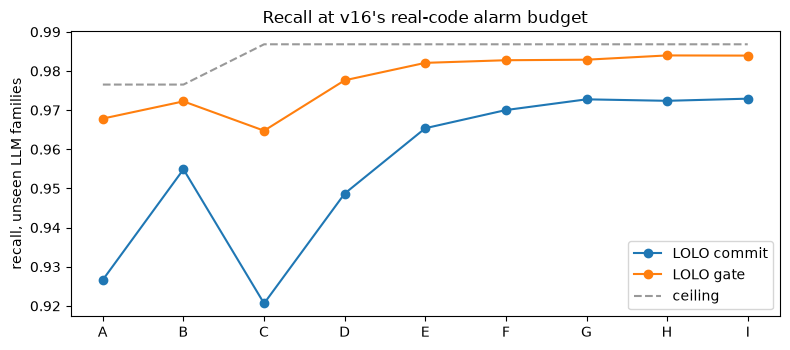

In [5]:
order = ["A_v16", "B_v16_capacity", "C_extractors", "D_extractors_capacity", "E_real_negatives_4k",
         "F_real_negatives_12k", "G_deeper", "H_more_real_negatives", "I_deeper_more_negatives"]
what = {"A_v16": "v16 recipe, round-1 data", "B_v16_capacity": "+ cleaning r2, depth 7 x 600 trees",
        "C_extractors": "cleaning r2 + extractors, v16 size", "D_extractors_capacity": "+ depth 7 x 600",
        "E_real_negatives_4k": "+ real-code negatives (4k files)", "F_real_negatives_12k": "+ real-code negatives (12k files)",
        "G_deeper": "F at depth 9 x 800", "H_more_real_negatives": "F with 30k files", "I_deeper_more_negatives": "depth 9 x 800 + 30k files"}
res = {k: json.loads((R2 / f"{k}.json").read_text()) for k in order}
print(f"{'run':24}{'change':38}{'ceiling':>8}{'val clean':>20}{'LOLO':>20}")
print(f"{'':70}{'commit':>10}{'gate':>10}{'commit':>10}{'gate':>10}")
for k in order:
    r = res[k]; v = r["val"]["clean"]; lo = r["lolo"]
    print(f"{k:24}{what[k]:38}{lo['ceiling']:8.4f}{v['R@budget_commit']:10.4f}{v['R@budget_gate']:10.4f}"
          f"{lo['R@budget_commit']:10.4f}{lo['R@budget_gate']:10.4f}")
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(order))
ax.plot(x, [res[k]["lolo"]["R@budget_commit"] for k in order], "o-", label="LOLO commit")
ax.plot(x, [res[k]["lolo"]["R@budget_gate"] for k in order], "o-", label="LOLO gate")
ax.plot(x, [res[k]["lolo"]["ceiling"] for k in order], "--", color="#999", label="ceiling")
ax.set_xticks(x, [k.split("_")[0] for k in order]); ax.set_ylabel("recall, unseen LLM families")
ax.set_title("Recall at v16's real-code alarm budget"); ax.legend(); plt.tight_layout(); plt.show()

**Reading the table:**
- **Capacity (B)** is the biggest single model-side win. At the commit budget, LOLO recall goes from 92.7% to 95.5%. v16 used v0.4's hyperparameters (depth 5, 300 trees), which were never tuned.
- **Extractors alone (C)** raise the ceiling (97.7% → 98.7%) but *lose* recall at the budget. Their extra candidates on real code use up the alarm budget, and a small model can't tell them apart.
- **Real-code negative mining (E, F, H)** fixes that. Candidates from sampled **train-split** OSS files are added as negatives: unlabeled, but nearly secret-free. The model then sees what the new extractors fire on in ordinary code.
- **Neither class weighting nor re-enabling name features** changed anything (earlier LOLO runs), so both stay as in v16.
- **H and I tie**, so **H** (depth 7, 600 trees, negatives from 30k files) is the simpler v17 recipe.

## 16. v17 candidate

```
python scripts/train_v11.py --train data/synthetic_v4_clean.jsonl data/eval/train_v5.jsonl data/eval/llm_train_v5.jsonl \
  --val data/eval/val_v5.jsonl --test data/eval/test_v5.jsonl data/trufflehog_golden.jsonl \
  --pipeline-features --zero-features <v16's 10 name features> --monotone --scale-pos-weight 2 \
  --max-depth 7 --n-estimators 600 --real-negatives 30000 --alarm-budget commit=14.9 gate=56.8 \
  --target-recall 0.97 0.90 --out data/models/v17.json
```

**Threshold policy change (working rule 4):** v17's thresholds are chosen to match v16's real-code alarm rate, not a validation recall target:
- commit: 0.5317
- gate: 0.1579 (0.1580 after the rounding fix in section 18)

Trade-off: noise on real code stays equal to v16 by construction, and recall rises. The numbers are only as representative as the 16 val-split repos.

**Latency (NFR-01)** on 400 val-split files, full `detect_file_with_ml`:
- v16: p50 1.1 ms, p95 7.6 ms
- v17: p50 0.9 ms, p95 7.3 ms

ONNX scores candidates in batches, so the bigger forest costs nothing measurable.

In [6]:
r17 = json.loads((ROOT / "data/models/v17.report.json").read_text())
print("v17:", {k: r17[k] for k in ("train_rows", "real_negative_rows", "max_depth", "n_estimators")},
      "| zeroed", len(r17["zeroed_features"]), "| thresholds", {k: round(v, 4) for k, v in r17["thresholds"].items()})
for layer in ("commit", "gate"):
    print(f"  val candidates at {layer}: {r17['val'][layer]}")

v17: {'train_rows': 157429, 'real_negative_rows': 63246, 'max_depth': 7, 'n_estimators': 600} | zeroed 10 | thresholds {'0.97': 0.4853, '0.9': 0.8512, 'commit': 0.5317, 'gate': 0.158}
  val candidates at commit: {'records': 12455, 'auc': 0.9969, 'recall': 0.968, 'precision': 0.9406}
  val candidates at gate: {'records': 12455, 'auc': 0.9969, 'recall': 0.9912, 'precision': 0.7887}


## 17. Held-out scoring (once): v16 vs v17, full file scans

Scored after v17 was fixed by the validation evidence above, with `bench/compare_scanners.py`, the same five-scanner harness as round 1. Nothing here fed back into v17.

**Scored twice, for a reason unrelated to the results.** Code review of the first v17 found bugs:
- the round-2 URL extractor dropped padded base64 path segments, missed `HTTPS://`, and kept trailing `).` punctuation;
- the round-2 metrics ignored provider-regex false alarms on non-secrets and could cut inside tied scores;
- the hash-name drop rule looked at the whole line, not just the assigned name.

After the fixes, every experiment in section 15 was re-run: same ranking, same recipe. v17 was retrained with the same command, and these sets were scored again. The first scoring's numbers were within 0.6 points of these (largest change: OSS-test gate precision, 93.4% → 94.0%) and changed no decision.

In [7]:
f = lambda x: "  n/a" if x is None else f"{x:.3f}"
print(f"{'set':18}{'model':12}{'recall':>8}{'precision':>10}{'FPR':>7}{'ceiling':>9}")
for s in ("benchmark_llm_v5", "test_v5"):
    for tag, pre in (("v16 commit", "cmp6_commit"), ("v17 commit", "cmp7_commit"), ("v16 gate", "cmp6_gate"), ("v17 gate", "cmp7_gate")):
        path = ROOT / f"data/models/{pre}_{s}.json"
        if not path.exists() or not path.read_text().strip():
            print(f"{s:18}{tag:12}   (not run)"); continue
        d = json.loads(path.read_text()); v = d["scanners"]["harpocrates"]
        fpr = v["fp"] / max(v["fp"] + v["tn"], 1)
        print(f"{s:18}{tag:12}{f(v['recall']):>8}{f(v['precision']):>10}{fpr:7.3f}{d['harpocrates_candidate_coverage']:9.3f}")
d = json.loads((ROOT / "data/models/cmp7_gate_benchmark_llm_v5.json").read_text())
print()
print("benchmark, other scanners:", {n: (f(v["recall"]), f(v["precision"])) for n, v in d["scanners"].items() if n != "harpocrates"})
print("positives only one scanner caught:", {n: v["count"] for n, v in d["only"].items()})

set               model         recall precision    FPR  ceiling
benchmark_llm_v5  v16 commit     0.902     0.951  0.042    0.941
benchmark_llm_v5  v17 commit     0.940     0.943  0.052    0.955
benchmark_llm_v5  v16 gate       0.933     0.925  0.068    0.941
benchmark_llm_v5  v17 gate       0.951     0.895  0.100    0.955
test_v5           v16 commit     0.953     0.973  0.027    0.993
test_v5           v17 commit     0.987     0.972  0.028    0.995
test_v5           v16 gate       0.987     0.935  0.069    0.993
test_v5           v17 gate       0.994     0.940  0.064    0.995

benchmark, other scanners: {'trufflehog': ('0.400', '0.976'), 'gitleaks': ('0.523', '0.893'), 'detect_secrets': ('0.553', '0.638'), 'credsweeper': ('0.683', '0.728')}
positives only one scanner caught: {'trufflehog': 3, 'gitleaks': 0, 'detect_secrets': 12, 'credsweeper': 10, 'harpocrates': 203}


## Round 2 results and notes

**Full file scans, held-out benchmark (unseen Kimi + MiniMax code):**

| Model and threshold | Recall | Precision | FP |
| --- | --- | --- | --- |
| v16 commit | 90.2% | 95.2% | 95 |
| **v17 commit** | **94.0%** | 94.3% | 118 |
| v16 gate | 93.3% | 92.6% | 155 |
| **v17 gate** | **95.1%** | 89.6% | 229 |

**OSS test:**
- commit: 95.3% → **98.7%** recall, precision unchanged (97.3% → 97.2%)
- gate: 98.7% → **99.4%** recall, precision 93.5% → 94.0%

The benchmark's candidate ceiling rose from 94.1% to 95.5%. The gate target from round 1 (≥ 95% recall at ≥ 80% precision) is met.

**Per type (gate, benchmark):**
- password 61% → 76%
- generic random 68% → 77%
- Discord 90% → 95%
- ADO 89% → 92%
- JDBC 95% → 97%
- AWS secret key 98% → 100%
- Twilio and Vault up about 1.5 points
- no type got worse

Secrets that only Harpocrates caught: 203; TruffleHog 3, gitleaks 0, detect-secrets 12, CredSweeper 10.

**Where v17 is weaker:** gate precision on the benchmark fell 3 points (74 more false positives). Thresholds hold *real-code* noise equal to v16, but the benchmark's negatives are LLM-written look-alike slots, not real code. On real code the two models are noise-equal by construction.

**Notes for later rounds:**
- **The ceiling is still the main limit.** Passwords (75%) and generic random (77%) are mostly candidates never extracted: very short passwords, and values on the line after their key. Those need a multi-line scanner, not a better model.
- **The real-code negatives are unlabeled.** A few may be real secrets committed in OSS test fixtures. Candidates the model scores highest should go to the DATA-05 review queue before a release.
- **The alarm budget comes from only 16 val-split repos (6,850 files).** A larger val split would make it more stable.
- **Calibration (FR-CORE-03) is still open.** v17's scores are uncalibrated: the gate threshold of 0.16 is a rank cut-off, not a probability.
- **Validation is saturated for clean generators.** Future rounds should keep LOLO plus the real-code budget as the primary yardsticks.

**v17 is a candidate, not shipped.** Shipping would mean:
- replacing `model.onnx`, `xgboost_model.json` and `model_config.json`, with thresholds commit 0.5317 and gate 0.1580 (section 18);
- rerunning the README comparison;
- updating `docs/data.md` for the round-2 data.

## 18. Release checks after an external review

An outside review of the v16 → v17 write-up (GPT-6-sol via Codex) agreed that v17 is a sound replacement, with a stronger case at commit than at gate. It asked for four checks before settling the gate policy:
1. stability by repo, with paired uncertainty;
2. an audit of mined negatives that look like secrets, plus an ablation without them;
3. a blinded audit of real-code alarms, reporting *verified* false redactions;
4. freezing the thresholds and retiring the benchmark for model selection.

All four are below (`scripts/r2_audit.py`). Check 3 needs human labels.

**Found while running them:** the trainer rounded budget thresholds *down* to 4 decimals. v17's gate threshold of 0.1579 admitted a cluster of near-identical scores, giving 398 alarms against a budget of 389. Budget thresholds now round up, so the gate is **0.1580** (386 alarms), and the model is unchanged. The held-out numbers in section 17 were measured at 0.1579. They were not re-scored, because the benchmark is now retired (check 4).

In [8]:
rc = json.loads((R2 / "release_checks.json").read_text())
print("Check 1a: recall gain on validation, paired bootstrap over", rc["recall_gain"]["commit"]["groups"], "repos/files")
for layer, g in rc["recall_gain"].items():
    print(f"  {layer:6} v16 {g['v16_recall']:.4f} -> v17 {g['v17_recall']:.4f}  gain {g['gain']:+.4f}  "
          f"95% CI [{g['ci95'][0]:+.4f}, {g['ci95'][1]:+.4f}]  secrets only v17 catches {g['v17_only']}, only v16 {g['v16_only']}")
print()
print("Check 1b: ML alarms per 1,000 real files (thresholds frozen; test-split repos are reported, never used to choose)")
for split in ("val", "test"):
    for layer in ("commit", "gate"):
        a, b = rc["alarm_rates"][split][f"v16_{layer}"], rc["alarm_rates"][split][f"v17_{layer}"]
        x = np.array([a["per_repo"][k] for k in sorted(a["per_repo"])]); y = np.array([b["per_repo"][k] for k in sorted(b["per_repo"])])
        print(f"  {split:4} {layer:6} overall v16 {a['overall_per_1k']:6.1f}  v17 {b['overall_per_1k']:6.1f} | per-repo median {np.median(x):5.1f} -> {np.median(y):5.1f}"
              f", max {x.max():6.1f} -> {y.max():6.1f} | v17 higher in {int((y > x).sum())} of {len(x)} repos")

Check 1a: recall gain on validation, paired bootstrap over 1051 repos/files
  commit v16 0.9515 -> v17 0.9835  gain +0.0319  95% CI [+0.0262, +0.0399]  secrets only v17 catches 87, only v16 2
  gate   v16 0.9816 -> v17 0.9899  gain +0.0083  95% CI [+0.0050, +0.0127]  secrets only v17 catches 22, only v16 0

Check 1b: ML alarms per 1,000 real files (thresholds frozen; test-split repos are reported, never used to choose)
  val  commit overall v16   14.9  v17   14.9 | per-repo median  11.8 ->   9.6, max  171.3 ->  160.2 | v17 higher in 5 of 16 repos
  val  gate   overall v16   56.8  v17   56.4 | per-repo median  62.5 ->  58.9, max  596.7 ->  447.5 | v17 higher in 5 of 16 repos
  test commit overall v16   20.7  v17   16.3 | per-repo median   0.0 ->   0.0, max  267.9 ->  196.4 | v17 higher in 10 of 42 repos
  test gate   overall v16  136.7  v17   68.6 | per-repo median  22.4 ->  17.4, max  949.5 ->  399.0 | v17 higher in 12 of 42 repos


**Check 1, stability:**
- **Recall.** The gain is well outside noise: commit +3.2 points (CI 2.6 to 4.0), gate +0.8 (CI 0.5 to 1.3). v17 loses almost nothing v16 caught (2 secrets at commit, 0 at gate).
- **Noise on repos no threshold ever saw.** On the 42 untouched test-split repos, v17 is *quieter*: commit 20.7 → 16.3 and gate 136.7 → 68.6 alarms per 1,000 files. Equal alarms on the 16 validation repos did carry over, and in v17's favor.
- **Per-repo variation is large.** A few repos hold most of the alarms (up to 950 per 1,000 files for v16), so any single-repo number means little.

In [9]:
mn = rc["mined_negatives"]
print(f"Check 2: {mn['mined_rows']} mined real-code negatives; a model fit without them scores "
      f"{mn['score_ge_0.9']} at >= 0.9 and {mn['score_ge_0.5']} at >= 0.5 (top {mn['top_k_written']} in data/audit/mined_negatives_top.csv)")
print(f"{'ablation':24}{'mined rows kept':>16}{'LOLO commit':>13}{'LOLO gate':>11}{'val-clean commit':>18}")
for k in ("H_more_real_negatives", "J_reliable_0.9", "K_reliable_0.5"):
    r = json.loads((R2 / f"{k}.json").read_text())
    kept = (r.get("mined_rows_kept") or [r.get("real_negative_rows")])[0]
    print(f"{k:24}{kept:16}{r['lolo']['R@budget_commit']:13.4f}{r['lolo']['R@budget_gate']:11.4f}{r['val']['clean']['R@budget_commit']:18.4f}")

Check 2: 63246 mined real-code negatives; a model fit without them scores 363 at >= 0.9 and 2627 at >= 0.5 (top 100 in data/audit/mined_negatives_top.csv)
ablation                 mined rows kept  LOLO commit  LOLO gate  val-clean commit
H_more_real_negatives              63246       0.9724     0.9840            0.9835
J_reliable_0.9                     62883       0.9716     0.9840            0.9831
K_reliable_0.5                     60619       0.9698     0.9828            0.9793


**Check 2, positive–unlabeled risk: real, but not where the gain comes from.**

The mined negatives a model trained without them finds most secret-like (read by hand, not printed here) are almost all **credential-shaped test fixtures and demo values**:
- the well-known jwt.io example token and other test JWTs;
- Supabase's public demo anon and service keys in a docker test;
- keystore salts in local docker volumes;
- HMAC secrets in test files;
- `user:pass@` URIs in schema examples.

Probably none are live credentials, but they are exactly what the gate should redact. Mining them teaches "a credential in a fixture is not a secret."

The ablation shows those rows don't drive the gain:
- **J** keeps only reliable negatives: it drops the 363 rows scoring ≥ 0.9, with the filter model refit inside every fold. It ties v17 (H).
- **K** drops the 2.6k rows scoring ≥ 0.5 and costs about 0.3 points.

**Recommendation:** J (`train_v11.py ... --reliable-below 0.9`) gives the same performance with less label-policy risk.

In [10]:
import csv
blind, key = ROOT / "data/audit/alarms_blind.csv", ROOT / "data/audit/alarms_key.json"
bs = rc["blind_sample"]
print(f"Check 3: gate alarms on val-split OSS files: v16 {bs['alarms']['v16']}, v17 {bs['alarms']['v17']}; "
      f"groups {bs['groups']}; blinded sample {bs['sampled']}")
labels = {r["id"]: r["label (secret / not_secret / unsure)"].strip() for r in csv.DictReader(open(blind))} if blind.exists() else {}
done = {k: v for k, v in labels.items() if v in ("secret", "not_secret")}
if len(done) < len(labels) * 0.9 or not labels:
    print(f"  labels: {len(done)} of {len(labels)} done - verified false redactions pending human labels")
else:
    k = json.loads(key.read_text()); files = int(C.oss_rows("val")["n_files"])
    fp_rate = {g: np.mean([done[i] == "not_secret" for i in done if k[i]["group"] == g]) for g in bs["sampled"]}
    est = {"v16": fp_rate["both"] * bs["groups"]["both"] + fp_rate["v16_only"] * bs["groups"]["v16_only"],
           "v17": fp_rate["both"] * bs["groups"]["both"] + fp_rate["v17_only"] * bs["groups"]["v17_only"]}
    print("  share not a secret by group:", {g: round(v, 3) for g, v in fp_rate.items()})
    print("  estimated verified false redactions per 1,000 files:", {m: round(1000 * v / files, 1) for m, v in est.items()})

Check 3: gate alarms on val-split OSS files: v16 389, v17 386; groups {'both': 206, 'v17_only': 180, 'v16_only': 183}; blinded sample {'v17_only': 80, 'v16_only': 40, 'both': 80}
  labels: 0 of 200 done - verified false redactions pending human labels


**Check 3, blinded audit (pending labels).** `data/audit/alarms_blind.csv` holds 200 gate alarms sampled from three groups: 80 flagged only by v17, 40 only by v16, and 80 by both. Each is shown with 3 lines of context and its candidate marked `⟦…⟧`. The file shows no model or score; the key is kept separately in `alarms_key.json`. Only 206 of about 390 alarms are shared (matched one-to-one by file, line and overlapping token), so the two models disagree on nearly half their real-code alarms, and that disagreement is what this audit settles.

Label each row `secret`, `not_secret` or `unsure`, then re-run this section. Both files are git-ignored: they hold real strings from the OSS corpus.

**Check 4, holdout reuse.** `benchmark_llm_v5` has been scored for v14, v15, v16 and twice for v17, so it is retired for model selection and kept only as a historical record. The thresholds are frozen at commit 0.5317 and gate 0.1580. Future rounds select on LOLO plus the real-code budget; the next held-out benchmark needs code from an LLM family not used so far.

## 19. Shipped: detector v1.2 = model v17, recipe J

**Decision:** ship J, which is v17's recipe with reliable-negative mining (`--reliable-below 0.9`). It ties H on every validation yardstick (section 18) and doesn't teach "a credential in a fixture is not a secret."

Command, the same as section 16 plus `--reliable-below 0.9 --out data/models/v17j.json`. The trained model is installed as `cli/Harpocrates/ml/models/xgboost_model.json`, converted to ONNX, and the ONNX predictions were checked identical to the scored candidate.

**Held-out, reported once for the README.** The model choice was already made, and the benchmark is retired for selection, so this is a report, not a selection step. It used the same harness as section 17. The stability checks from section 18 were repeated for J (`r2_audit.py report ... --candidate v17j`).

In [11]:
rj = json.loads((R2 / "release_checks_v17j.json").read_text())
cfg = json.loads((ROOT / "cli/Harpocrates/ml/models/model_config.json").read_text())
print("shipped:", cfg["version"], "| thresholds", {k: cfg["thresholds"][k] for k in ("commit", "gate")})
print(f"{'set':18}{'threshold':11}{'v16 recall':>11}{'v17 recall':>11}{'v16 prec':>10}{'v17 prec':>10}")
for s in ("benchmark_llm_v5", "test_v5"):
    for layer in ("commit", "gate"):
        a = json.loads((ROOT / f"data/models/cmp6_{layer}_{s}.json").read_text())["scanners"]["harpocrates"]
        b = json.loads((ROOT / f"data/models/cmp8_{layer}_{s}.json").read_text())["scanners"]["harpocrates"]
        print(f"{s:18}{layer:11}{a['recall']:11.3f}{b['recall']:11.3f}{a['precision']:10.3f}{b['precision']:10.3f}")
print("candidate AUC:", cfg["metrics"]["auc_candidates"])
for layer, g in rj["recall_gain"].items():
    print(f"validation recall gain at {layer}: {g['gain']:+.4f} (95% CI {g['ci95'][0]:+.4f} to {g['ci95'][1]:+.4f}), secrets only v16 catches: {g['v16_only']}")
for split in ("val", "test"):
    print(f"{split}-split repos, ML alarms per 1k files:",
          {l: (round(rj['alarm_rates'][split][f'v16_{l}']['overall_per_1k'], 1), round(rj['alarm_rates'][split][f'v17_{l}']['overall_per_1k'], 1)) for l in ("commit", "gate")})

shipped: 1.2.0 | thresholds {'commit': 0.5559, 'gate': 0.1904}
set               threshold   v16 recall v17 recall  v16 prec  v17 prec
benchmark_llm_v5  commit           0.902      0.939     0.951     0.944
benchmark_llm_v5  gate             0.933      0.950     0.925     0.904
test_v5           commit           0.953      0.987     0.973     0.971
test_v5           gate             0.987      0.993     0.935     0.945
candidate AUC: {'benchmark_llm_v5': 0.9856, 'test_v5': 0.9996}
validation recall gain at commit: +0.0316 (95% CI +0.0260 to +0.0389), secrets only v16 catches: 1
validation recall gain at gate: +0.0083 (95% CI +0.0050 to +0.0127), secrets only v16 catches: 0
val-split repos, ML alarms per 1k files: {'commit': (14.9, 14.9), 'gate': (56.8, 56.8)}
test-split repos, ML alarms per 1k files: {'commit': (20.7, 16.6), 'gate': (136.7, 62.7)}


**Result:**
- **Benchmark:** commit 90.2% → 93.9% recall (precision 95.2% → 94.4%); gate 93.3% → 95.0% (92.6% → 90.4%).
- **OSS test:** commit 95.3% → 98.7% (97.3% → 97.1%); gate 98.7% → 99.3% (93.5% → 94.5%).
- **Untouched test repos:** gate alarms fall from 136.7 to 62.7 per 1,000 files.
- **Compared with H:** J's benchmark gate precision is higher (90.4% against 89.6%) at the same recall.

**Still open:**
- the blinded alarm audit (section 18, check 3);
- calibration (FR-CORE-03);
- multi-line extraction (a password on the line after its key);
- a new held-out benchmark from an unused LLM family.